# 04 — Diagnosing the shift

Notebook 03 left a specific clue rather than a vague failure. The model's tolerance in
proper-motion space is **not fixed**: it accepts RR Lyrae up to about a mas/yr from the LMC
centroid, and Cepheids only within about 0.2. Same galaxy, same bulk motion, wildly different
rule.

A tolerance that changes between populations is a tolerance that depends on *something else*.
This notebook finds out what, and does it by testing hypotheses rather than by picking the
first plausible story.

The plan:

1. Locate both real populations inside the simulated distribution, feature by feature.
2. Measure the shift with a distance, then with a classifier that names the culprit for us.
3. Test the obvious explanation — *trees cannot extrapolate* — and **reject it**.
4. Establish what is actually happening, and prove it by surgery on individual stars.
5. Look at the machinery underneath, and see why feature importance could never have warned us.
6. Show that the RR Lyrae failure has a *different* cause, and that it is partly irreducible.

Everything here uses the **`dev`** half of the real catalogues. `lock` stays sealed until
notebook 06.

In [1]:
import json
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy import stats
from sklearn.metrics import roc_auc_score

import lmc
from lmc import models
from lmc.metrics import wilson_ci, fmt_recall
from lmc.split import SEED

LMC_C, MW_C, CEPH_C, RRL_C = "#ff8c42", "#6b8cae", "#2ec4b6", "#9b5de5"

sim = lmc.load_sim(verbose=True)
real = pl.read_parquet("../data/processed/real_lmc.parquet")

dev = real.filter((pl.col("split") == "dev") & pl.col("astrometry_ok") & pl.col("photometry_ok"))
ceph = dev.filter(pl.col("catalogue") == "cepheid")
rrl = dev.filter(pl.col("catalogue") == "rrlyrae")

is_lmc = (sim["Type"] == 1).to_numpy()
simL = sim.filter(pl.col("Type") == 1)

model_dir, clf, FEATURES = models.load("v1_baseline")

def score(frame):
    return clf.predict_proba(frame.select(FEATURES).to_numpy().astype(np.float32))[:, 1]

print(f"simulated LMC: {simL.height:,}   dev Cepheids: {ceph.height:,}   dev RR Lyrae: {rrl.height:,}")

  loaded 1,269,704 rows from data/processed/train_clean.parquet
simulated LMC: 277,177   dev Cepheids: 2,254   dev RR Lyrae: 10,665


## 1. Where do the real stars sit inside the training distribution?

The most direct question available. For each of the eleven features, take the median real star
and ask: what percentile of the **simulated LMC** does it fall at?

A value near 50% means the simulation describes real stars well on that axis. A value near 0 or
100 means the model is being asked about a kind of star it was told is rare.

In [2]:
print(f"{'feature':<20} {'sim LMC med':>12} | {'Cepheid med':>12} {'pctile':>8} "
      f"| {'RR Lyr med':>11} {'pctile':>8}")
print("-" * 84)
pct = {}
for f in FEATURES:
    v = simL[f].to_numpy()
    row = f"{f:<20} {np.median(v):>12.3f} |"
    for cat, frame in (("cepheid", ceph), ("rrlyrae", rrl)):
        m = float(np.median(frame[f].to_numpy()))
        p = 100 * (v < m).mean()
        pct[(f, cat)] = p
        flag = " *" if (p < 5 or p > 95) else "  "
        row += f" {m:>12.3f} {p:>6.1f}%{flag}" + (" |" if cat == "cepheid" else "")
    print(row)
print("\n  * = the median real star sits in the outer 5% of the simulated LMC on this axis")

feature               sim LMC med |  Cepheid med   pctile |  RR Lyr med   pctile
------------------------------------------------------------------------------------
pmra                        1.858 |        1.802   35.5%   |        1.843   45.7%  
pmdec                       0.385 |        0.331   34.6%   |        0.360   42.2%  
pm_total                    1.904 |        1.862   38.4%   |        1.977   67.6%  
parallax                    0.020 |       -0.007   45.9%   |       -0.003   46.5%  
pmra_error                  0.191 |        0.039    2.1% * |        0.271   72.7%  
pmdec_error                 0.170 |        0.042    4.0% * |        0.294   83.1%  
parallax_error              0.344 |        0.032    0.0% * |        0.219   24.0%  
phot_g_mean_mag            18.976 |       15.910    1.3% * |       19.313   69.0%  
phot_bp_mean_mag           19.346 |       16.221    1.2% * |       19.504   60.7%  
phot_rp_mean_mag           18.419 |       15.386    1.8% * |       18.896   69

That table splits the problem in two, and the split is clean.

**On motion — `pmra`, `pmdec`, `pm_total`, `parallax`, and the colour `bp_rp` — both
populations sit between the 34th and 68th percentile.** Utterly ordinary. The simulation
describes real LMC kinematics well.

**On the three measurement errors and the three magnitudes, the Cepheids are off the end of the
scale.** Their median G sits at the **1.3rd percentile** of simulated LMC members; their median
`parallax_error` at the **0th**. In the simulation, a star like a real Cepheid barely exists.

And the RR Lyrae — the population that mostly *works* — sit at the 69th, 73rd and 83rd
percentiles on those same axes. Comfortably inside.

So the two catalogues are not two samples of one problem. **The Cepheids fail because they are
photometrically and astrometrically unlike anything the simulation calls an LMC star.** Whatever
is wrong with the RR Lyrae is something else, and section 7 handles it separately.

## 2. Measuring the shift, and letting a classifier name it

The percentile table is a hand-read. Two standard tools make it a measurement.

**The Kolmogorov–Smirnov distance** is the largest vertical gap between two cumulative
distributions, $D = \sup_x |F_{\text{sim}}(x) - F_{\text{real}}(x)|$ — a single number in
$[0, 1]$ for how far apart two samples are, with no assumption that either is Gaussian.

**Adversarial validation** is the better tool, and it generalises to any deployment. Label
simulated LMC stars 0 and real LMC stars 1, then train a classifier to tell them apart. If it
succeeds, the two populations are trivially distinguishable — which is precisely the condition
under which a model trained on one cannot be trusted on the other. And its feature importances
*name the offending columns*, without anyone having to guess which to inspect.

feature                KS vs Cepheids   KS vs RR Lyrae
parallax_error                  0.907            0.506
phot_bp_mean_mag                0.889            0.299
phot_g_mean_mag                 0.872            0.486
phot_rp_mean_mag                0.862            0.487
pmra_error                      0.783            0.492
pmdec_error                     0.739            0.612
bp_rp                           0.379            0.523
parallax                        0.362            0.073
pmdec                           0.249            0.254
pmra                            0.185            0.185
pm_total                        0.154            0.227

sorted by distance from the Cepheids. 0 = identical, 1 = no overlap at all.


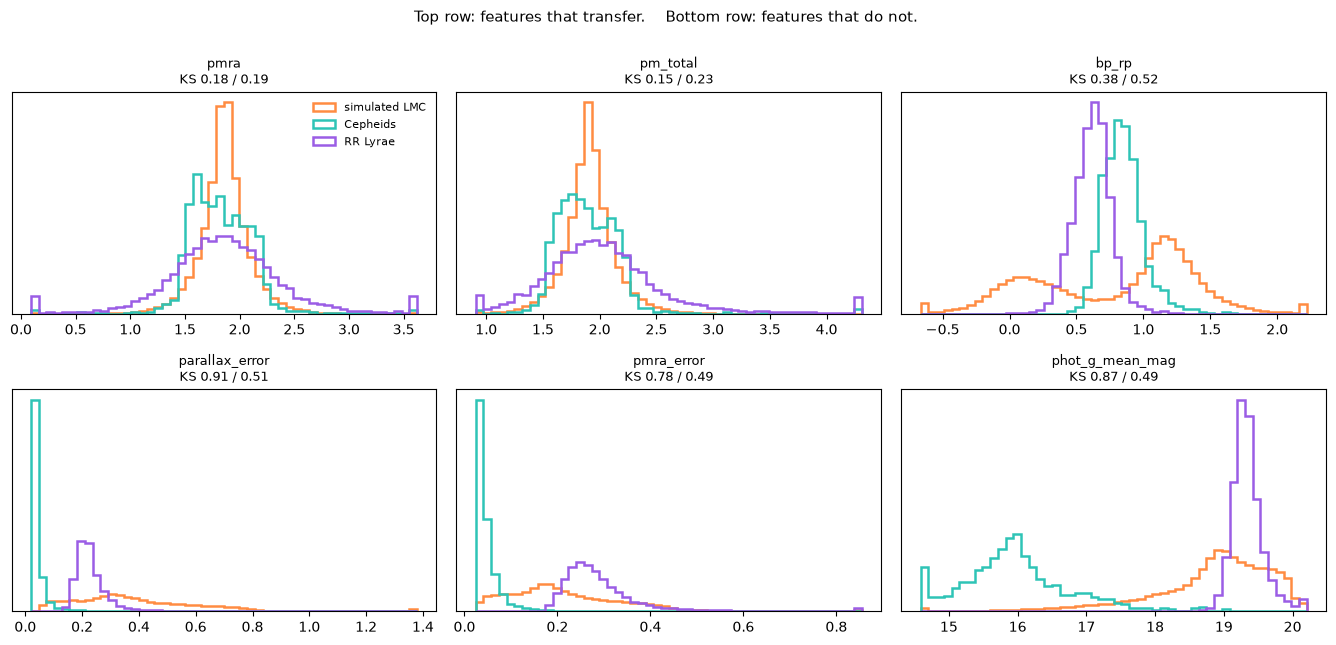

In [3]:
rng = np.random.default_rng(SEED)
sub = rng.choice(simL.height, 20_000, replace=False)     # KS on 277k x 2k is needlessly slow

print(f"{'feature':<20} {'KS vs Cepheids':>16} {'KS vs RR Lyrae':>16}")
ks = {}
for f in FEATURES:
    a = simL[f].to_numpy()[sub]
    d_c = stats.ks_2samp(a, ceph[f].to_numpy()).statistic
    d_r = stats.ks_2samp(a, rrl[f].to_numpy()).statistic
    ks[f] = (d_c, d_r)
for f, (d_c, d_r) in sorted(ks.items(), key=lambda kv: -kv[1][0]):
    print(f"{f:<20} {d_c:>16.3f} {d_r:>16.3f}")
print("\nsorted by distance from the Cepheids. 0 = identical, 1 = no overlap at all.")

# The table as a picture: which axes do the real stars actually live on?
show = ["pmra", "pm_total", "bp_rp", "parallax_error", "pmra_error", "phot_g_mean_mag"]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 6.4))
for ax, f in zip(axes.ravel(), show):
    a = simL[f].to_numpy()[sub]
    lo, hi = np.percentile(np.concatenate([a, ceph[f].to_numpy(), rrl[f].to_numpy()]), [0.5, 99.5])
    for name, fr, c in (("simulated LMC", simL, LMC_C), ("Cepheids", ceph, CEPH_C),
                        ("RR Lyrae", rrl, RRL_C)):
        ax.hist(np.clip(fr[f].to_numpy(), lo, hi), bins=50, range=(lo, hi), density=True,
                histtype="step", lw=1.8, color=c, label=name)
    d_c, d_r = ks[f]
    ax.set_title(f"{f}\nKS {d_c:.2f} / {d_r:.2f}", fontsize=9.5)
    ax.set_yticks([])
    if f == show[0]:
        ax.legend(frameon=False, fontsize=8)
fig.suptitle("Top row: features that transfer.    Bottom row: features that do not.",
             fontsize=11, y=1.0)
plt.tight_layout(); plt.show()


In [4]:
# Adversarial validation: can a model tell simulated LMC from real LMC?
adv_rows = pl.concat([
    simL.select(FEATURES).with_columns(pl.lit(0).alias("is_real")),
    dev.select(FEATURES).with_columns(pl.lit(1).alias("is_real")),
])
Xa = adv_rows.select(FEATURES).to_numpy().astype(np.float32)
ya = adv_rows["is_real"].to_numpy()

n = len(ya)
perm = rng.permutation(n)
cut = int(0.7 * n)
tr, te = perm[:cut], perm[cut:]

adv = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                        scale_pos_weight=(ya == 0).sum() / (ya == 1).sum(),
                        tree_method="hist", n_jobs=-1, random_state=SEED,
                        eval_metric="logloss")
adv.fit(Xa[tr], ya[tr])
auc = roc_auc_score(ya[te], adv.predict_proba(Xa[te])[:, 1])

print(f"simulated LMC vs real LMC — ROC-AUC = {auc:.4f}")
print("(0.5 would mean indistinguishable; 1.0 means trivially separable)\n")
print("what gave it away:")
for f, v in sorted(zip(FEATURES, adv.feature_importances_), key=lambda kv: -kv[1])[:6]:
    print(f"  {f:<20} {v:.4f}")

simulated LMC vs real LMC — ROC-AUC = 1.0000
(0.5 would mean indistinguishable; 1.0 means trivially separable)

what gave it away:
  parallax_error       0.3521
  pmdec_error          0.3413
  pmra_error           0.1725
  bp_rp                0.0573
  pmdec                0.0444
  phot_g_mean_mag      0.0136


**ROC-AUC 1.0000.** A model separates simulated LMC stars from real LMC stars perfectly — they
are, statistically, two different populations. And the importances point straight at the
measurement errors, with the magnitudes behind them: the same columns the percentile table
flagged, with no human having decided where to look.

One caution on reading that ranking. It tells you which columns most efficiently *distinguish*
the two domains, which is not the same as which columns most damage *the classifier*. Section 5
measures the second thing directly, and finds photometry matters roughly as much as the errors
despite ranking lower here. Adversarial validation is a detector, not an attribution.

Even so, this is the transferable technique in this notebook. Any time a model is about to meet
data it was not trained on, this is ten lines and it answers "are these the same kind of thing?"
before the deployment answers it for you.

## 3. Hypothesis A: trees cannot extrapolate — tested, and rejected

A gradient-boosted tree is a piecewise-constant function. It carves feature space with axis-
aligned cuts and returns a fixed value inside each region. Push a value below the lowest split
threshold any tree ever makes and there is no cut left to distinguish it: everything down there
falls into one region, and the model returns whatever that region meant during training.

Real Cepheids have `pmra_error` around 0.039 against the simulated LMC's median of 0.191. It is
very tempting to conclude they have fallen off the bottom edge of the model's knowledge.

That is a testable claim, so test it.

In [5]:
booster = clf.get_booster()
booster.feature_names = FEATURES     # trained on a bare array, so names were f0..f10

td = booster.trees_to_dataframe()
splits = td[td.Feature != "Leaf"]

print(f"{'feature':<20} {'splits':>8} {'lowest threshold':>18} {'% of Cepheids below it':>24}")
for f in FEATURES:
    s = splits[splits.Feature == f]["Split"]
    if not len(s):
        continue
    below = 100 * (ceph[f].to_numpy() < s.min()).mean()
    print(f"{f:<20} {len(s):>8,} {s.min():>18.5f} {below:>23.1f}%")

print(f"\nThe 400 trees make {len(splits):,} splits in total.")

feature                splits   lowest threshold   % of Cepheids below it
pmra                    1,969           -2.61690                     0.0%
pmdec                   2,259           -2.95829                     0.1%
pm_total                1,588            0.59023                     0.1%
parallax                1,917           -2.14434                     0.0%
pmra_error              1,735            0.02861                    15.8%
pmdec_error               319            0.02518                     6.5%
parallax_error             36            0.14396                    98.2%
phot_g_mean_mag         1,318           12.42479                     0.2%
phot_bp_mean_mag        1,500           12.82012                     0.2%
phot_rp_mean_mag        1,572           11.84142                     0.2%
bp_rp                   2,360           -0.16966                     0.0%

The 400 trees make 16,573 splits in total.


Mostly, no — but read the table carefully, because one row does not fit the headline.

For the columns that carry the failure, the Cepheids are **inside** the model's range: 15.8%
fall below the lowest `pmra_error` cut, 6.5% below the lowest `pmdec_error` cut, and 0.2% below
the lowest magnitude cut. The model has thousands of thresholds spanning the region these stars
occupy.

`parallax_error` is the exception, and a real one: **98.2% of Cepheids sit below its lowest
threshold**, so on that axis they genuinely are off the edge. But it is used for just 36 of the
16,573 splits and carries 0.3% of the model's importance. A column the model barely consults
cannot account for a 74-point collapse.

So extrapolation is happening in one corner, and it is not where the damage is. The other half
of the test settles it. If the Cepheids were in unexplored territory, the region of feature space
they occupy should be *sparse* in training data. Is it?

In [6]:
g = sim["phot_g_mean_mag"].to_numpy()
e = sim["pmra_error"].to_numpy()

# The cell the real Cepheids actually live in.
cell = (g >= 15) & (g < 17) & (e >= 0.02) & (e < 0.06)
print(f"real Cepheids: median G = {np.median(ceph['phot_g_mean_mag']):.2f}, "
      f"median pmra_error = {np.median(ceph['pmra_error']):.3f}")
print(f"simulated stars in G 15-17 and pmra_error 0.02-0.06:  {cell.sum():,}")
print(f"  of which LMC members: {is_lmc[cell].sum():,}  ({100*is_lmc[cell].mean():.2f}%)")
print(f"\nThat region holds {100*cell.mean():.1f}% of the entire training set. It is not empty.")
print("It is densely populated — and the simulation labels it overwhelmingly Milky Way.")

real Cepheids: median G = 15.91, median pmra_error = 0.039
simulated stars in G 15-17 and pmra_error 0.02-0.06:  173,784
  of which LMC members: 12,671  (7.29%)

That region holds 13.7% of the entire training set. It is not empty.
It is densely populated — and the simulation labels it overwhelmingly Milky Way.


**Hypothesis A is rejected.** The Cepheids are not in a blank part of the map. They sit in a
region containing over a hundred thousand training examples — more than a tenth of the whole
dataset — where the simulation says the answer is *Milky Way*.

This matters, because "trees can't extrapolate" would have been a satisfying and quotable
explanation, and acting on it would have led somewhere useless. The model is not confused. It is
confidently applying a rule it was correctly taught.

## 4. What is actually happening

Here is the rule, read straight out of the training data: P(LMC) as a function of brightness and
astrometric precision.

P(LMC) in the simulated training set
              err 0.0-0.05  err 0.05-0.1  err 0.1-0.25  err 0.25-3.0
G 12-16               3.3%             —             —             —
G 16-18               8.9%         16.2%             —             —
G 18-19                  —         20.6%         33.4%             —
G 19-21                  —             —         36.4%         21.4%

real Cepheids sit in the top-left cell:   G ~15.9, err ~0.039
real RR Lyrae sit in the bottom-right:    G ~19.3, err ~0.271


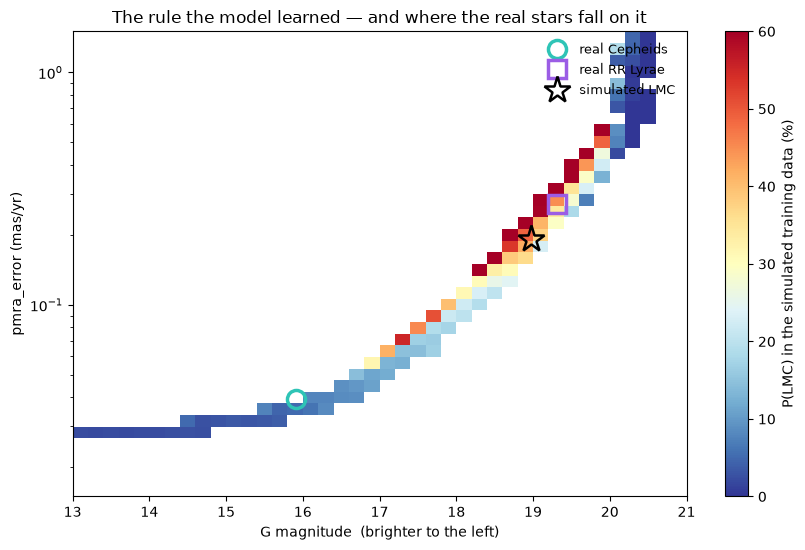

Blue is 'the simulation says foreground here'. The real Cepheids sit deep in it.
The RR Lyrae sit next to the simulated LMC, which is why they mostly survive.


In [7]:
g_bins = [(12, 16), (16, 18), (18, 19), (19, 21)]
e_bins = [(0.00, 0.05), (0.05, 0.10), (0.10, 0.25), (0.25, 3.0)]

print("P(LMC) in the simulated training set")
print(f"{'':<12}" + "".join(f"{f'err {lo}-{hi}':>14}" for lo, hi in e_bins))
grid = np.full((len(g_bins), len(e_bins)), np.nan)
for i, (glo, ghi) in enumerate(g_bins):
    row = f"G {glo}-{ghi}".ljust(12)
    for j, (elo, ehi) in enumerate(e_bins):
        m = (g >= glo) & (g < ghi) & (e >= elo) & (e < ehi)
        if m.sum() > 500:
            grid[i, j] = 100 * is_lmc[m].mean()
            row += f"{grid[i, j]:>13.1f}%"
        else:
            row += f"{'—':>14}"
    print(row)

print(f"\nreal Cepheids sit in the top-left cell:   G ~{np.median(ceph['phot_g_mean_mag']):.1f}, "
      f"err ~{np.median(ceph['pmra_error']):.3f}")
print(f"real RR Lyrae sit in the bottom-right:    G ~{np.median(rrl['phot_g_mean_mag']):.1f}, "
      f"err ~{np.median(rrl['pmra_error']):.3f}")


# The same grid at higher resolution, as a map, with the real populations on it.
g_edges = np.linspace(13, 21, 41)
e_edges = np.logspace(np.log10(0.015), np.log10(1.5), 41)
H_all, _, _ = np.histogram2d(g, e, bins=[g_edges, e_edges])
H_lmc, _, _ = np.histogram2d(g[is_lmc], e[is_lmc], bins=[g_edges, e_edges])
frac = np.where(H_all >= 50, H_lmc / np.maximum(H_all, 1), np.nan)

fig, ax = plt.subplots(figsize=(8.6, 5.6))
im = ax.pcolormesh(g_edges, e_edges, 100 * frac.T, cmap="RdYlBu_r", vmin=0, vmax=60,
                   shading="flat")
ax.set_yscale("log")
ax.set_xlabel("G magnitude  (brighter to the left)")
ax.set_ylabel("pmra_error (mas/yr)")
fig.colorbar(im, ax=ax, label="P(LMC) in the simulated training data (%)")

for name, fr, c, mk in (("real Cepheids", ceph, CEPH_C, "o"), ("real RR Lyrae", rrl, RRL_C, "s")):
    ax.plot(np.median(fr["phot_g_mean_mag"]), np.median(fr["pmra_error"]), mk, ms=13,
            mfc="none", mec=c, mew=2.5, label=name)
ax.plot(np.median(simL["phot_g_mean_mag"]), np.median(simL["pmra_error"]), "*", ms=20,
        mfc="none", mec="k", mew=1.8, label="simulated LMC")
ax.legend(frameon=False, loc="upper right", fontsize=9)
ax.set_title("The rule the model learned — and where the real stars fall on it")
plt.tight_layout(); plt.show()

print("Blue is 'the simulation says foreground here'. The real Cepheids sit deep in it.")
print("The RR Lyrae sit next to the simulated LMC, which is why they mostly survive.")


There it is.

In the simulation, **bright and precisely-measured means foreground.** That is not a bug in
XGBoost, and it is not noise — it is a real, strong, correctly-learned regularity of the
training data. The simulated LMC is a faint population: its median member sits at G = 18.98, and
almost none of it is as bright as a Cepheid.

And in the sky, it is false. Classical Cepheids are supergiants — among the most luminous stars
any galaxy contains. The LMC has thousands of them. They are bright *because* they are LMC
members, not in spite of it.

So the failure is not extrapolation into the unknown. It is **confident interpolation into a
densely-populated region where the simulation's labels do not describe reality.** The model
learned the simulation correctly. The simulation is wrong about what an LMC star looks like.

That also explains notebook 03's variable tolerance. The model does not have one rule for
proper motion; it has a rule that trades off motion against brightness and precision. Feed it a
star that is bright and precisely measured, and the evidence from those columns is so strongly
"foreground" that the motion has to be nearly perfect to overcome it. Feed it a faint, noisily-
measured star — an RR Lyrae — and those columns say "LMC", so the motion is allowed to be
sloppier.

## 5. Proof by surgery

If that is right, it makes a sharp prediction: take a real Cepheid, **change nothing about how
it moves**, and merely relabel how brightly it shines and how well it was measured — and the
model should change its mind.

In [8]:
med = {c: float(np.median(simL[c])) for c in FEATURES}

ERRORS = ["pmra_error", "pmdec_error", "parallax_error"]
PHOTOM = ["phot_g_mean_mag", "phot_bp_mean_mag", "phot_rp_mean_mag", "bp_rp"]
PARALX = ["parallax"]

def swap(frame, cols):
    return frame.with_columns([pl.lit(med[c]).alias(c) for c in cols]) if cols else frame

print("recall after replacing groups of columns with the simulated-LMC median value")
print("(proper motion is never touched)\n")
print(f"{'columns replaced':<34} {'Cepheids':>10} {'RR Lyrae':>10}")
print("-" * 56)
for tag, cols in [
    ("nothing — as Gaia observed them", []),
    ("the 3 measurement errors", ERRORS),
    ("the 4 photometry columns", PHOTOM),
    ("parallax", PARALX),
    ("errors + photometry", ERRORS + PHOTOM),
    ("errors + photometry + parallax", ERRORS + PHOTOM + PARALX),
]:
    line = f"{tag:<34}"
    for frame in (ceph, rrl):
        line += f"{100*(score(swap(frame, cols)) >= 0.5).mean():>9.2f}%"
    print(line)

recall after replacing groups of columns with the simulated-LMC median value
(proper motion is never touched)

columns replaced                     Cepheids   RR Lyrae
--------------------------------------------------------
nothing — as Gaia observed them       22.32%    76.82%
the 3 measurement errors              57.45%    72.36%
the 4 photometry columns              68.10%    60.44%
parallax                              21.69%    77.28%
errors + photometry                   89.44%    54.57%
errors + photometry + parallax        89.57%    55.42%


The prediction holds, and the detail is instructive.

For the **Cepheids**, neither group alone is the whole story — the errors recover part of the
gap, the photometry recovers a comparable part, and **together they recover most of it**. That
is what a genuine multi-feature covariate shift looks like: no single guilty column, but a set
of columns that all carry an absolute scale the simulation sets differently from the sky.
Parallax contributes nothing, which is consistent with it holding 0.3% of the model's importance.

For the **RR Lyrae**, the same surgery makes things *worse*. Of course it does — their errors and
magnitudes already sit near the simulated medians, so overwriting them destroys real information
and gains nothing. Confirmation, from the opposite direction, that this diagnosis is about the
Cepheids specifically.

Note what this rules out. It is not the model's treatment of proper motion, which was never
altered. It is not a threshold. It is not sample size. Eleven features went in and the failure
lives in seven of them — every one carrying units the simulation calibrated to itself.

## 6. The machinery underneath — and why importance could not have warned us

Notebook 02 printed a feature-importance ranking and drew a conclusion from it: proper motion
93.7%, the three error columns 1.6% between them. On that evidence the error columns looked
close to irrelevant.

They were not irrelevant. They were most of a 74-point failure. Understanding why that ranking
was misleading means knowing what the number actually measures, which means opening up what
XGBoost does when it fits a tree.

**The objective.** Each boosting round adds a tree $f_t$ to the running raw prediction, and
approximates the loss to second order around the current prediction:

$$\mathcal{L}^{(t)} \simeq \sum_i \left[ g_i f_t(x_i) + \tfrac12 h_i f_t(x_i)^2 \right]
                       + \tfrac12 \lambda \sum_j w_j^2$$

with $g_i$ and $h_i$ the first and second derivatives of the loss at the current prediction. For
logistic loss those are famously simple:

$$g_i = p_i - y_i \qquad h_i = p_i(1 - p_i)$$

**The leaf value.** Every row in leaf $j$ gets the same value $w_j$, so the objective restricted
to that leaf is a quadratic in one variable, $G_j w + \tfrac12 (H_j + \lambda) w^2$ where
$G_j = \sum_{i \in j} g_i$ and $H_j = \sum_{i \in j} h_i$. Differentiate, set to zero:

$$w_j^* = -\frac{G_j}{H_j + \lambda}$$

**The split.** Substituting $w^*$ back gives each leaf a score $-\tfrac12 G^2/(H+\lambda)$, so
splitting a node into left and right improves the objective by

$$\text{gain} = \tfrac12\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda}
                            - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma$$

and the tree greedily takes the largest gain available. **That gain, summed over every split a
feature is used for, is exactly the "importance" notebook 02 plotted.**

Rather than take any of that on faith, fit a two-leaf stump and reproduce its numbers by hand.

In [9]:
# A deliberately tiny model: one tree, one split, no shrinkage, so every number is checkable.
rng_s = np.random.default_rng(SEED)
samp = rng_s.choice(sim.height, 40_000, replace=False)
Xs = sim.select(FEATURES).to_numpy()[samp].astype(np.float32)
ys = sim["Type"].to_numpy()[samp]

LAMBDA, GAMMA, SPW = 1.0, 0.0, float((ys == 0).sum() / (ys == 1).sum())

stump = xgb.XGBClassifier(
    n_estimators=1, max_depth=1, learning_rate=1.0, base_score=0.5,
    reg_lambda=LAMBDA, gamma=GAMMA, scale_pos_weight=SPW,
    tree_method="exact", n_jobs=-1, random_state=SEED, eval_metric="logloss")
stump.fit(Xs, ys)

sb = stump.get_booster(); sb.feature_names = FEATURES
tdf = sb.trees_to_dataframe()
print(tdf[["ID", "Feature", "Split", "Gain", "Cover"]].to_string(index=False), "\n")

# base_score = 0.5 -> the initial raw prediction is 0, so p = 0.5 for every row.
p0 = np.full(len(ys), 0.5)
w = np.where(ys == 1, SPW, 1.0)          # scale_pos_weight acts as a per-row sample weight
gi = w * (p0 - ys)                        # gradient of logistic loss
hi = w * p0 * (1 - p0)                    # hessian

leaf = sb.predict(xgb.DMatrix(Xs, feature_names=FEATURES), pred_leaf=True).astype(int)

print("leaf values:   w* = -G / (H + lambda)")
for node in np.unique(leaf):
    m = leaf == node
    G, H = gi[m].sum(), hi[m].sum()
    mine = -G / (H + LAMBDA)
    theirs = float(tdf.loc[tdf.ID == f"0-{node}", "Gain"].iloc[0])   # leaf rows store w in Gain
    print(f"  leaf {node}: n={m.sum():>6,}  G={G:>12.3f}  H={H:>10.3f}   "
          f"mine {mine:+.8f}   xgboost {theirs:+.8f}")
    assert abs(mine - theirs) < 1e-5, "leaf weight formula disagrees"

root = tdf[tdf.Feature != "Leaf"].iloc[0]
left = leaf == int(root.Yes.split("-")[1])
GL, HL = gi[left].sum(), hi[left].sum()
GR, HR = gi[~left].sum(), hi[~left].sum()

gain = 0.5 * (GL**2/(HL+LAMBDA) + GR**2/(HR+LAMBDA)
              - (GL+GR)**2/(HL+HR+LAMBDA)) - GAMMA

print(f"\nsplit gain on {root.Feature} < {root.Split:.4f}")
print(f"  paper formula (with the 1/2):  {gain:>16.4f}")
print(f"  what XGBoost reports:          {root.Gain:>16.4f}")
print(f"  ratio:                         {root.Gain / gain:>16.4f}")

# Exactly 2. XGBoost's internal CalcGain is G^2/(H+lambda) with no 1/2, so the
# reported loss_chg is twice the actual reduction in the objective. The factor is
# constant across every candidate split, so it never changes which split wins --
# which is how a discrepancy this size survives in production code.
assert abs(root.Gain / gain - 2.0) < 1e-4
assert abs(2 * gain - root.Gain) / root.Gain < 1e-4
print("\nThe leaf weights match exactly. The gain is out by a factor of 2 -- not an error,")
print("a convention: XGBoost drops the 1/2, and since it drops it from every candidate")
print("split equally, the arg-max is unaffected. Worth knowing before comparing a gain")
print("against anything computed from the paper.")

 ID  Feature    Split         Gain       Cover
0-0 pm_total 2.608696 52062.812500 15614.00000
0-1     Leaf      NaN     1.709337  8321.36035
0-2     Leaf      NaN    -1.950428  7292.63916 

leaf values:   w* = -G / (H + lambda)
  leaf 1: n=11,088  G=  -14225.722  H=  8321.361   mine +1.70933729   xgboost +1.70933723
  leaf 2: n=28,912  G=   14225.722  H=  7292.639   mine -1.95042854   xgboost -1.95042849

split gain on pm_total < 2.6087
  paper formula (with the 1/2):        26031.4054
  what XGBoost reports:                52062.8125
  ratio:                                   2.0000

The leaf weights match exactly. The gain is out by a factor of 2 -- not an error,
a convention: XGBoost drops the 1/2, and since it drops it from every candidate
split equally, the arg-max is unaffected. Worth knowing before comparing a gain
against anything computed from the paper.


So importance is a sum of training gains. Read the formula again and notice what is in it:
$g_i$, $h_i$, and the training rows. **Nothing in it knows anything about a distribution the
model was not trained on.**

A feature earns importance by reducing training loss. It becomes *dangerous* by having a
different distribution at deployment time. Those are unrelated properties, and importance
measures only the first. A column can carry 0.6% of the gain and 100% of the risk, which is
precisely what happened here.

The tool that measures the second property is section 2's adversarial validation. Run both.

## 7. The RR Lyrae are failing for a different reason

Section 1 showed the RR Lyrae sit at ordinary percentiles on every axis, and section 5 showed
the surgery that helps Cepheids hurts them. So their 76.8% is not the same problem, and fixing
the Cepheid problem will not necessarily fix theirs.

Section 1 also left a loose thread from notebook 03: the real populations are **wider** in
proper motion than the simulated one.

In [10]:
k = 1.4826       # MAD -> sigma for a Gaussian
def spread(a):
    return k * np.median(np.abs(a - np.median(a)))

mu_ra, mu_dec = np.median(simL["pmra"]), np.median(simL["pmdec"])

print(f"{'population':<18} {'spread pmra':>12} {'spread pmdec':>13} {'median pm error':>17}")
for name, fr in (("simulated LMC", simL), ("real Cepheids", ceph), ("real RR Lyrae", rrl)):
    print(f"{name:<18} {spread(fr['pmra'].to_numpy()):>12.3f} "
          f"{spread(fr['pmdec'].to_numpy()):>13.3f} {np.median(fr['pmra_error']):>17.3f}")

print("\nThe simulated clump is about half the width of the real one.")
print("Some of that is measurement noise, but the Cepheids are measured 5x more precisely")
print("than the simulation and are still wider — so part of it is real internal motion")
print("the simulation does not reproduce: the LMC rotates, and GOG's version is too cold.\n")

for name, fr in (("Cepheids", ceph), ("RR Lyrae", rrl)):
    off = np.hypot(fr["pmra"].to_numpy() - mu_ra, fr["pmdec"].to_numpy() - mu_dec)
    print(f"{name:<10} more than 1 mas/yr from the LMC centroid: {100*(off > 1).mean():5.1f}%")

population          spread pmra  spread pmdec   median pm error
simulated LMC             0.170         0.152             0.191
real Cepheids             0.289         0.385             0.039
real RR Lyrae             0.438         0.595             0.271

The simulated clump is about half the width of the real one.
Some of that is measurement noise, but the Cepheids are measured 5x more precisely
than the simulation and are still wider — so part of it is real internal motion
the simulation does not reproduce: the LMC rotates, and GOG's version is too cold.

Cepheids   more than 1 mas/yr from the LMC centroid:   2.4%
RR Lyrae   more than 1 mas/yr from the LMC centroid:  20.1%


**One in five RR Lyrae is genuinely more than a mas/yr away from the LMC's mean motion** — and
that number sits right next to their recall ceiling. Those stars are not being misclassified
because of a domain shift. Their *measured* proper motion really is inconsistent with the clump,
either because they are faint and noisily measured, or because the catalogue's membership label
is optimistic.

Before accepting that, rule out the obvious alternative: bad astrometry, flagged as such by
Gaia. `ruwe` is the standard goodness-of-fit statistic for a source's astrometric solution, and
values above 1.4 conventionally mark a solution not to be trusted.

In [11]:
print(f"{'':<12} {'ruwe > 1.4':>12} {'median ruwe':>13} {'median G':>10} {'median pm error':>17}")
for name, fr in (("Cepheids", ceph), ("RR Lyrae", rrl)):
    r = fr["ruwe"].to_numpy(); r = r[np.isfinite(r)]
    print(f"{name:<12} {100*(r > 1.4).mean():>11.1f}% {np.median(r):>13.3f} "
          f"{np.median(fr['phot_g_mean_mag']):>10.2f} {np.median(fr['pmra_error']):>17.3f}")

print("\nThe flag points the WRONG WAY: the Cepheids, which the model handles worst,")
print("have nearly three times the bad-astrometry rate of the RR Lyrae.\n")

good = rrl.filter(pl.col("ruwe") <= 1.4)
k_all, n_all = int((score(rrl) >= 0.5).sum()), rrl.height
k_gd, n_gd = int((score(good) >= 0.5).sum()), good.height
print(f"RR Lyrae recall, all stars:        {fmt_recall(k_all, n_all)}")
print(f"RR Lyrae recall, ruwe <= 1.4 only: {fmt_recall(k_gd, n_gd)}")
print(f"\nCutting on ruwe removes {n_all - n_gd:,} stars and moves recall by "
      f"{100*(k_gd/n_gd - k_all/n_all):+.2f} points. It is not the explanation.")

               ruwe > 1.4   median ruwe   median G   median pm error
Cepheids             9.8%         1.027      15.91             0.039
RR Lyrae             3.1%         1.019      19.31             0.271

The flag points the WRONG WAY: the Cepheids, which the model handles worst,
have nearly three times the bad-astrometry rate of the RR Lyrae.

RR Lyrae recall, all stars:         76.82% [76.01, 77.61]  (8,193/10,665)
RR Lyrae recall, ruwe <= 1.4 only:  78.72% [77.92, 79.50]  (8,133/10,332)

Cutting on ruwe removes 333 stars and moves recall by +1.90 points. It is not the explanation.


Quality flags are not the answer.

The flag points the wrong way — bad astrometric solutions are three times more common among the
Cepheids, the population the model handles *worst* — and cutting on it recovers 1.9 points of a
roughly 20-point shortfall while discarding 333 stars. Real, marginal, and nowhere near an
explanation.

What actually predicts an RR Lyrae failure is how faint it is:

In [12]:
gmag = rrl["phot_g_mean_mag"].to_numpy()
p_rrl = score(rrl)
edges = [16, 18.5, 19, 19.5, 20, 21.5]

print(f"{'G range':<14} {'n':>8} {'median pm error':>17} {'spread pmra':>13} {'recall':>10}")
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (gmag >= lo) & (gmag < hi)
    if m.sum() < 100:
        continue
    print(f"{f'{lo} – {hi}':<14} {m.sum():>8,} {np.median(rrl['pmra_error'].to_numpy()[m]):>17.3f} "
          f"{spread(rrl['pmra'].to_numpy()[m]):>13.3f} {100*(p_rrl[m] >= 0.5).mean():>9.1f}%")

print("\nFainter -> larger errors -> wider scatter -> lower recall. A physical limit,")
print("not a modelling mistake: at G ~ 20 Gaia simply cannot measure the motion well")
print("enough to place a star in a clump 0.3 mas/yr wide.")

G range               n   median pm error   spread pmra     recall
18.5 – 19           366             0.208         0.339      76.2%
19 – 19.5         8,291             0.262         0.422      78.8%
19.5 – 20         1,788             0.341         0.513      75.3%
20 – 21.5           218             0.640         1.090      15.1%

Fainter -> larger errors -> wider scatter -> lower recall. A physical limit,
not a modelling mistake: at G ~ 20 Gaia simply cannot measure the motion well
enough to place a star in a clump 0.3 mas/yr wide.


## 8. The ablation, run as diagnosis

The natural response to "seven of the eleven features are shifted" is to retrain without them
and see what happens. That is what this table does — but it is worth being precise about its
status, because it is the most dangerous cell in the notebook.

**This is diagnosis, not model selection.** It is run on the `dev` half. If the winning feature
set is chosen by reading the Cepheid column, then that column has become a training signal, and
quoting it later as validation would be dishonest. Notebook 06 reports the sealed `lock` half,
and says out loud that the choice was made here.

In [13]:
from lmc.split import make_split

y_all = sim["Type"].to_numpy()
train_idx, test_idx = make_split(y_all)
spw = (y_all[train_idx] == 0).sum() / (y_all[train_idx] == 1).sum()

SETS = {
    "v1  all 11 features": FEATURES,
    "    minus photometry": ["pmra", "pmdec", "pm_total", "parallax",
                             "pmra_error", "pmdec_error", "parallax_error"],
    "    minus errors": ["pmra", "pmdec", "pm_total", "parallax",
                         "phot_g_mean_mag", "phot_bp_mean_mag", "phot_rp_mean_mag", "bp_rp"],
    "    motion + parallax": ["pmra", "pmdec", "pm_total", "parallax"],
    "    motion only": ["pmra", "pmdec", "pm_total"],
}

from sklearn.metrics import average_precision_score

print(f"{'feature set':<24} {'sim PR-AUC':>11} {'sim purity':>11} "
      f"{'Cepheid recall (dev)':>30} {'RR Lyrae recall (dev)':>30}")
print("-" * 110)
for tag, feats in SETS.items():
    X = sim.select(feats).to_numpy().astype(np.float32)
    m = xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                          subsample=0.9, colsample_bytree=0.9, scale_pos_weight=spw,
                          tree_method="hist", n_jobs=-1, random_state=SEED,
                          eval_metric="logloss")
    m.fit(X[train_idx], y_all[train_idx])

    p_te = m.predict_proba(X[test_idx])[:, 1]
    hit = (p_te >= 0.5) & (y_all[test_idx] == 1)
    pur = hit.sum() / max((p_te >= 0.5).sum(), 1)
    ap = average_precision_score(y_all[test_idx], p_te)

    line = f"{tag:<24} {ap:>11.4f} {100*pur:>10.2f}%"
    for fr in (ceph, rrl):
        p = m.predict_proba(fr.select(feats).to_numpy().astype(np.float32))[:, 1]
        line += f"   {fmt_recall(int((p >= 0.5).sum()), fr.height):>27}"
    print(line)

feature set               sim PR-AUC  sim purity           Cepheid recall (dev)          RR Lyrae recall (dev)
--------------------------------------------------------------------------------------------------------------


v1  all 11 features           0.9992      98.04%    22.32% [20.64, 24.08]  (503/2,254)    76.82% [76.01, 77.61]  (8,193/10,665)


    minus photometry          0.9971      96.52%    22.09% [20.43, 23.85]  (498/2,254)    75.98% [75.16, 76.78]  (8,103/10,665)


    minus errors              0.9992      98.00%    25.42% [23.67, 27.26]  (573/2,254)    74.93% [74.10, 75.74]  (7,991/10,665)


    motion + parallax         0.9945      94.69%    97.60% [96.89, 98.16]  (2,200/2,254)    80.57% [79.81, 81.31]  (8,593/10,665)


    motion only               0.9925      94.61%    97.60% [96.89, 98.16]  (2,200/2,254)    80.70% [79.94, 81.44]  (8,607/10,665)


Three things to read off it.

**Dropping the shifted columns costs almost nothing in-domain and buys an enormous amount out of
domain.** Simulated PR-AUC falls from 0.9992 to 0.9945 — the fourth decimal place — while real
Cepheid recall goes from 22.3% to **97.6%**.

**Both groups have to go.** Removing the photometry alone leaves 22.1%; removing the errors alone
leaves 25.4%. Neither is the culprit on its own, which is exactly what the surgery predicted, now
confirmed by retraining from scratch.

**Nothing rescues the RR Lyrae past about 81%.** Every feature set lands there, because their
residual failures are stars whose measured motion genuinely disagrees with the clump. That is the
ceiling section 7 predicted, and no feature choice moves it.

But "delete the shifted features" is a blunt instrument, and it discards real information: how
well a star was measured genuinely does matter when judging whether its motion is consistent with
a clump. Notebook 05 keeps that information and removes the scale.

## 9. What this notebook establishes

- **Two failures, two causes.** On motion and colour, both real populations sit between the 34th
  and 68th percentile of the simulated LMC. On the measurement errors and the magnitudes the
  Cepheids sit in the outer 5% — median G at the **1.3rd percentile**, `parallax_error` at the
  **0th** — while the RR Lyrae sit comfortably inside at the 69th to 83rd.
- **The shift is measurable and self-identifying.** KS distance ranks the culprits
  (`parallax_error` 0.91, the magnitudes 0.86–0.89, against 0.15–0.25 for proper motion), and
  adversarial validation separates simulated from real LMC stars at **ROC-AUC 1.0000**, naming
  the same columns unprompted. Ten lines, applicable to any deployment.
- **"Trees cannot extrapolate" was tested and rejected.** Only 15.8% of Cepheids fall below the
  lowest `pmra_error` cut and 0.2% below the lowest magnitude cut. The one column where they
  genuinely are off the edge, `parallax_error` at 98.2%, is used for 36 of 16,573 splits and
  holds 0.3% of the importance.
- **The real mechanism: confident interpolation into a region the simulation mislabels.** The
  cell the Cepheids occupy — G 15–17, `pmra_error` 0.02–0.06 — holds **173,784 training rows,
  13.7% of the whole dataset**, and only **7.3%** of them are LMC. "Bright and precisely measured
  means foreground" is a strong, correctly-learned regularity of the simulation, and false in the
  sky, because Cepheids are supergiants and the LMC is full of them.
- **Proved by surgery.** Relabelling only the errors and the photometry — never touching proper
  motion — takes Cepheid recall from 22.3% to **89.4%**. Errors alone reach 57.5%, photometry
  alone 68.1%: a genuine multi-column shift, not one guilty feature. The same operation *hurts*
  the RR Lyrae (76.8% → 54.6%), whose values were already typical.
- **Feature importance could not have caught this**, and the derivation shows why: gain is a sum
  of $G^2/(H+\lambda)$ terms over *training* rows. It measures contribution to training loss and
  knows nothing about deployment distributions. The error columns held 1.6% of the importance and
  most of the failure. (The derivation also turned up a detail worth carrying: XGBoost's reported
  gain is twice the paper's, having dropped the ½ that is constant across candidate splits.)
- **The RR Lyrae ceiling is largely irreducible.** 20.1% are genuinely more than 1 mas/yr from
  the LMC's mean motion, against a recall ceiling near 81%. Not a data-quality artifact:
  `ruwe > 1.4` is three times more common among Cepheids (9.8% vs 3.1%), and cutting on it moves
  recall by 1.9 points. It is faintness — recall falls to **15.1%** for the RR Lyrae beyond
  G = 20, where the typical proper-motion error, 0.64 mas/yr, is twice the width of the clump
  being searched for.

**Next — notebook 05.** The lesson is not "measurement errors are bad features". It is that a
feature carrying an **absolute scale** transfers only if both domains share that scale. The fix
is to build features that are dimensionless — where a star's own error is the unit its deviation
is measured in — so that a Cepheid measured to 0.039 and a simulated star measured to 0.191 are
asked the same question.